In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk openpyxl spacy
!python -m spacy download en_core_web_sm



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\rodri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 2.2 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 2.2 MB/s eta 0:00:06
     ----- ---------------------------------- 1.8/12.8 MB 2.3 MB/s eta 0:00:05
     ------ --------------------------------- 2.1/12.8 MB 2.3 MB/s eta 0:00:05
     -------- ------------------------------- 2.6/12.8 MB 2.4 MB/s eta 0:00:05
     --------- ------------------------------ 2.9/12.8 MB 2.1 MB/s eta 0:00:05
     ---------- ----------------------------- 3.4/12.8 MB 2.1 MB/s eta 0:00:05
     ----------- ---------------------------- 3.7/12.8 MB 2.0 MB/s eta 0:00:05
     ------------- -------------------------- 4.2/12.8 MB 2.1 MB/s eta 0:00:05
     ------------- -------------------------- 4.5/12.8 MB 2.1 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.8 MB 2.1 MB/s


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\rodri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install bertopic


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\rodri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Middle Term Test 2 - COVID-19 Fake News Detection

## 1.1 Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist
from nltk.util import ngrams
from nltk.text import Text
import spacy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rodri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## 1.2 Load Dataset

In [4]:
# cargar datasets test, train, val, y text_with_labels
train_df = pd.read_excel('data/Constraint_English_Train.xlsx')
val_df = pd.read_excel('data/Constraint_English_Val.xlsx')
test_df = pd.read_excel('data/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('data/english_test_with_labels.xlsx') 

'''train_df = pd.read_excel('/content/Constraint_English_Train.xlsx')
val_df = pd.read_excel('/content/Constraint_English_Val.xlsx')
test_df = pd.read_excel('/content/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('/content/english_test_with_labels.xlsx')'''

# info basica
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# mostrar tweets completos
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

train_df.head(15)

Train shape: (6420, 3)
Validation shape: (2140, 3)
Test shape: (2140, 2)


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,real
1,2,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,real
2,3,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,real
4,5,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,real
5,6,"Covid Act Now found ""on average each person in Illinois with COVID-19 is infecting 1.11 other people. Data shows that the infection growth rate has declined over time this factors in the stay-at-home order and other restrictions put in place."" https://t.co/hhigDd24fE",real
6,7,If you tested positive for #COVID19 and have no symptoms stay home and away from other people. Learn more about CDC’s recommendations about when you can be around others after COVID-19 infection: https://t.co/z5kkXpqkYb. https://t.co/9PaMy0Rxaf,real
7,8,Obama Calls Trump’s Coronavirus Response A Chaotic Disaster https://t.co/DeDqZEhAsB,fake
8,9,"???Clearly, the Obama administration did not leave any kind of game plan for something like this.??�",fake
9,10,Retraction—Hydroxychloroquine or chloroquine with or without a macrolide for treatment of COVID-19: a multinational registry analysis - The Lancet https://t.co/L5V2x6G9or,fake


As a simple analysis we can see that there are shorter and longer tweets but most use hashtags and links to sources. We can also see that some use figures to describe what they say, in this small sample all those using figures are real but we will analyze more things below.

## 1.3 EDA (linguistic analysis)

### 1.3.1 Class distribution analysis

In [5]:
nltk.download('punkt')
nltk.download('stopwords')
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rodri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [6]:
df = train_df.copy()
df = df[['tweet', 'label']]

In [7]:
# distribución de clases
df['label'].value_counts()

label
real    3360
fake    3060
Name: count, dtype: int64

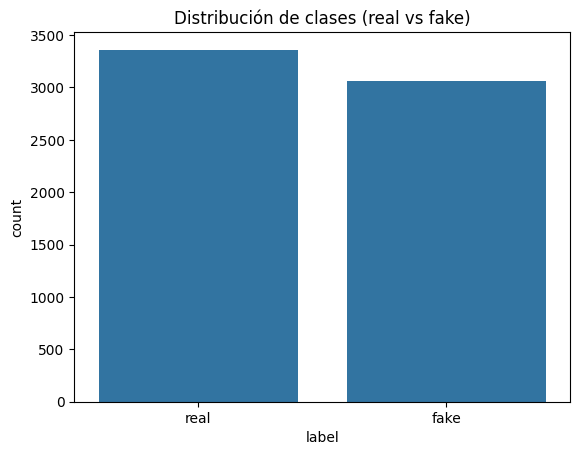

In [8]:
sns.countplot(data=df, x='label')
plt.title("Distribución de clases (real vs fake)")
plt.show()

There are more real than fake tweets, this will give us problems in numerical comparisons since they will be unbalanced.

### 1.3.4 Tokenization + stopwords + frequency

In [9]:
stop_words = set(stopwords.words("english"))

In [10]:
def preprocess_nltk(text):
    tokens = word_tokenize(text)
    return [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]

In [11]:
df['tokens'] = df['tweet'].astype(str).apply(preprocess_nltk)
df[['tweet', 'tokens']].head()

,tweet,tokens
0,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,"[cdc, currently, reports, deaths, general, discrepancies, death, counts, different, sources, small, explicable, death, toll, stands, roughly, people, today]"
1,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,"[states, reported, deaths, small, rise, last, tuesday, southern, states, reported, deaths, https]"
2,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,"[politically, correct, woman, almost, uses, pandemic, excuse, reuse, plastic, bag, https, coronavirus, nashville]"
3,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,"[indiafightscorona, covid, testing, laboratories, india, august, tests, done, profbhargava, dg, icmrdelhi, staysafe, indiawillwin, https]"
4,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,"[populous, states, generate, large, case, counts, look, new, cases, per, million, today, smaller, states, showing, cases, per, million, california, texas, al, ar, id, ks, ky, la, ms, nv, sc, https]"


### 1.3.2 Tweet length

In [12]:
df['tweet_length'] = df['tokens'].apply(len)

In [13]:
# estadisticas descriptivas por clase
df.groupby('label')['tweet_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3060.0,12.724837,18.592957,1.0,8.0,11.0,15.0,835.0
real,3360.0,16.702083,5.931704,2.0,12.0,17.0,21.0,34.0


The average is 12 for fake tweets and 16 for real ones, not much difference.

The maximum length of fake tweets is larger (835) but let's see why below:

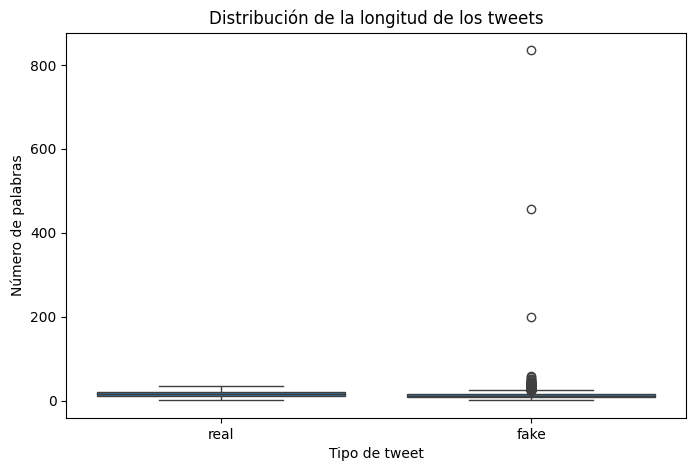

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='tweet_length')
plt.title("Distribución de la longitud de los tweets")
plt.ylabel("Número de palabras")
plt.xlabel("Tipo de tweet")
plt.show()

Fake tweets have several outliers or anomalies which are tweets with extremely large word counts.

In [15]:
df[df['tweet_length'] > 100][['tweet', 'label']].head()

tweet  \
270   Amoxi" Capsule made in US is the only medicine that can completely cure COVID-19.\nEgyptian Health Minister arrive in Italy with secret coronavirus cure.\n Dr Charles Lieber a Harvard professor has been arrested in the USA for manufacturing the coronavirus and selling it to China. A video news report from WCVB a TV station in Boston Massachusetts is shared with the Facebook post.\nMountain Matterhorn in Switzerland was lit in three colours of Indian flag as a token of gratitude to India for sending Hydroxychloroquine.\nAl-Azhar Imam said he is considering exceptions on Ramadan fasting as the research says that the mouth must be kept wet to prevent COVID-19\n Japanese Nobel Tasuku Honjo says coronavirus was created in the Wuhan laboratory\nA man collapses in 5 minutes after showing COVID-19 symptoms in India.\nCelebrities spreading misinformation about coronavirus and the Janata curfew in India.\n Multiple posts shared repeatedly on Facebook and Twitter since March 2020 claim that Israel has reported zero deaths from the novel coronavirus which causes the disease COVID-19. The posts also claim Israeli citizens have protected themselves from COVID-19 by drinking a remedy of hot water lemon and baking soda which purportedly “kills” the virus.\n CDC suddenly lost 30000 deaths from coronavirus from its data thus proving the virus is not as serious as it seems.\nPhotos of coronavirus patients being treated on the road in Italy.\nIndian actor Shah Rukh Khan donated money to Pakistan to fight coronavirus and did not help India at all.\nRussian President Vladimir Putin has ordered Russia’s population to stay at home for 15 days or face five years in jail.\nIndian Army has set-up a 1000 bed quarantine facility in Rajasthan's Barmer.\nLeonardo Da Vinci Hospital a COVID-19 reference hospital in Fortaleza Brazil is empty. A video "proves" there was no one at the areas open to the public.\n President Trump's claim that he inherited no ventilators from the Obama administration.\nAn audio where an unidentified person links the virus that causes COVID-19 with the massive flu vaccination campaign.\nBlack body bags being referred to as deaths in New York and the reason a lockdown is essential.\nMustard oil prevents a person from getting infected with COVID-19.\nNorth Carolina’s health department is "telling hospitals that if they decide to do elective surgeries they won’t be eligible to receive (protective equipment) from the state.”\n After coronavirus pandemic Chinese president said it's China's time to lead the world.\nThe nurses that Boris Johnson claimed saved his life are not registered in the UK.\nA claim that India’s Ministry of Home Affairs has made it a “punishable offense” for citizens to publish posts on social media about the novel coronavirus has been shared repeatedly on Facebook Twitter and WhatsApp.\n Says Nancy Pelosi was “caught trying to include abortion funding in bill to combat coronavirus.”\nA video of a man rebuking foreigners has been viewed thousands of times on social media alongside a claim that the Guinean government has ordered the arrest of all Chinese nationals in the country while awaiting the safe return of Guineans from China.\n The U.S. is the only country on earth that is protesting being locked down.\nPhoto of Kurnool MLA (Hafeez Khan) making a nurse to touch the feet of a religious head in Viswabharathi Medical College who had to come to the COVID-19 quarantine facility.\nNew York State Governor shows data that proves that isolation is ineffective against COVID-19.\nHomeopathic product Oscillococcinum protects against COVID-19.\nCDC admitted to lying about COVID-19 death stats.\nNotice for preparing emergency drugs was released on social media for alumni of Seoul National University College of Medicine.\nBelgian doctors turn their back on WHO director.\nDr. Li Wenliang (the Chinese whistleblower doctor) has proposed that drinking tea can cure COVID-19.\nAny person arrested for violating lockd

Now looking at them more closely they appear to be many tweets separated by \n as if they were not individual tweets but compilations or summaries of hoaxes since they are fake.

### 1.3.3 Lexical diversity

In [16]:
def lexical_diversity(tokens):
    return len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

In [17]:
tokens_real = [w for tokens in df[df['label'] == 'real']['tokens'] for w in tokens]
tokens_fake = [w for tokens in df[df['label'] == 'fake']['tokens'] for w in tokens]
lex_real = lexical_diversity(tokens_real)
lex_fake = lexical_diversity(tokens_fake)

print("Lexical diversity (REAL):", lex_real)
print("Lexical diversity (FAKE):", lex_fake)

Lexical diversity (REAL): 0.11076462517151053
Lexical diversity (FAKE): 0.22006780009245466


Fake tweets have more lexical diversity, probably real tweets repeat each other since real news are the same so they have shared vocabulary.

### 1.3.5 URL cleaning (https)
We need to clean the https tokens because they arise from links.

In [18]:
def preprocess_nltk_clean(text):
    tokens = word_tokenize(text)
    return [
        w.lower()
        for w in tokens
        if w.isalpha()
        and w.lower() not in stop_words
        and w.lower() != "https"
    ]

In [19]:
df['tokens_clean'] = df['tweet'].astype(str).apply(preprocess_nltk_clean)

### 1.3.6 Word frequency (by classes)
Here we will identify which words are most related to each class

In [20]:
tokens_real_clean = [w for tokens in df[df['label'] == 'real']['tokens_clean'] for w in tokens]
tokens_fake_clean = [w for tokens in df[df['label'] == 'fake']['tokens_clean'] for w in tokens]

In [21]:
fdist_real_clean = FreqDist(tokens_real_clean)
fdist_fake_clean = FreqDist(tokens_fake_clean)

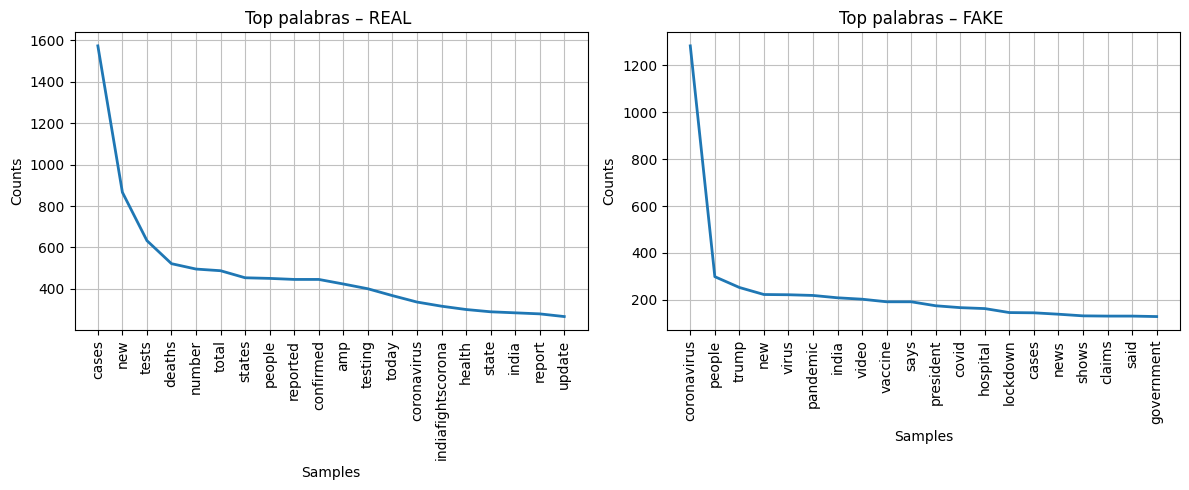

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
fdist_real_clean.plot(20, cumulative=False)
plt.title("Top palabras – REAL ")

plt.subplot(1,2,2)
fdist_fake_clean.plot(20, cumulative=False)
plt.title("Top palabras – FAKE ")

plt.tight_layout()
plt.show()

We can see that in fake tweets `coronavirus` predominates as the top word more than 1200 times. And in real tweets `cases` probably are tweets that report new or confirmed cases.

At first glance we can see that other words in fake tweets appear uniformly with no further predominance, meaning they are linguistically rich. While in real tweets we see much more `new`, `tests` or `deaths`.

### 1.3.7 N-grams

In [23]:
bigrams_real = list(ngrams(tokens_real_clean, 2))
bigrams_fake = list(ngrams(tokens_fake_clean, 2))

trigrams_real = list(ngrams(tokens_real_clean, 3))
trigrams_fake = list(ngrams(tokens_fake_clean, 3))

In [24]:
fdist_bi_real = FreqDist(bigrams_real)
fdist_bi_fake = FreqDist(bigrams_fake)

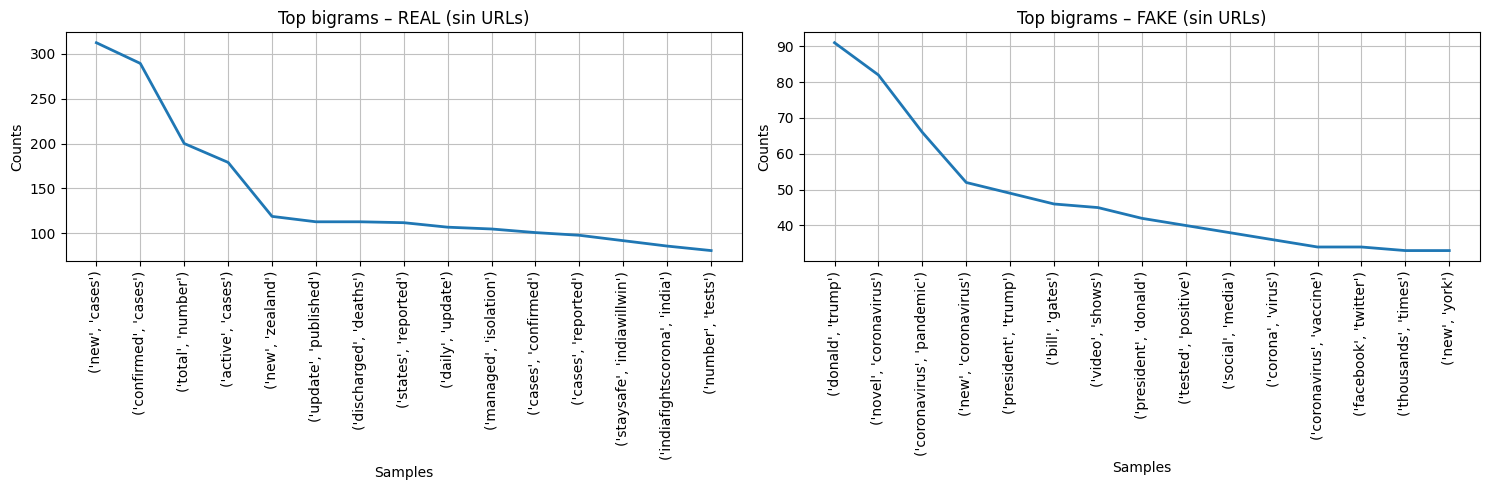

In [25]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
fdist_bi_real.plot(15, cumulative=False)
plt.title("Top bigrams – REAL (sin URLs)")

plt.subplot(1,2,2)
fdist_bi_fake.plot(15, cumulative=False)
plt.title("Top bigrams – FAKE (sin URLs)")

plt.tight_layout()
plt.show()

In n-grams we can see that the most common pair in real tweets is `new, cases` and `confirmed, cases` which tells us that real tweets are more related to new or confirmed cases and for example with `total, number` we can see what we saw at the beginning that they would be more related to putting figures.

As for fake tweets, the second most common is a link and then the word coronavirus probably hashtags that are usually put at the end right after the links like #coronavirus, as third we have `donald, trump` with almost 100 appearances.

We also have `coronavirus, pandemic` in fake tweets which we guess may be hashtags with the aim of drawing attention and alarming.

### 1.3.8 POS tagging

Continuing with linguistic analysis, now we will see analysis by pos tags, meaning word types.
Since there may be more real tweets than fake ones we will not use numbers but we will count and show percentages.

In [26]:
def pos_distribution(text):
    doc = nlp(text)
    return [token.pos_ for token in doc if token.is_alpha]

In [27]:
df['pos_tags'] = df['tweet'].astype(str).apply(pos_distribution)

In [28]:
# por clases
pos_real = [p for tags in df[df['label'] == 'real']['pos_tags'] for p in tags]
pos_fake = [p for tags in df[df['label'] == 'fake']['pos_tags'] for p in tags]
from collections import Counter

# Conteos
pos_real_counts = Counter(pos_real)
pos_fake_counts = Counter(pos_fake)

# Totales
total_pos_real = sum(pos_real_counts.values())
total_pos_fake = sum(pos_fake_counts.values())

# Frecuencias relativas
pos_real_freq = {k: v / total_pos_real for k, v in pos_real_counts.items()}
pos_fake_freq = {k: v / total_pos_fake for k, v in pos_fake_counts.items()}

In [29]:
pos_df = pd.DataFrame({
    'REAL': pd.Series(pos_real_freq),
    'FAKE': pd.Series(pos_fake_freq)
}).fillna(0)

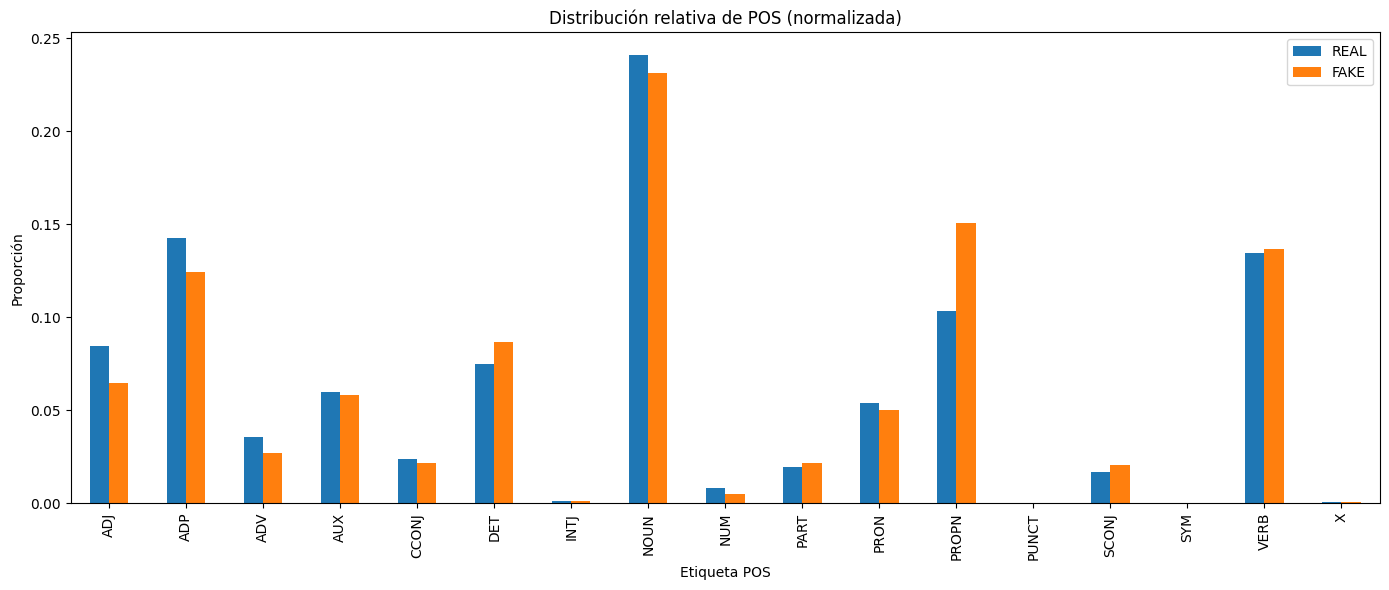

In [30]:
pos_df.plot(kind='bar', figsize=(14,6))
plt.title("Distribución relativa de POS (normalizada)")
plt.ylabel("Proporción")
plt.xlabel("Etiqueta POS")
plt.legend()
plt.tight_layout()
plt.show()

We can see that as expected, nouns predominate similarly in both, where we can see the greatest difference is in proper nouns where fake tweets predominate over real ones.

Perhaps this proper noun thing is because there tends to be a more personal language and more emotional or persuasive discourse.

### 1.3.9 Named Entity Recognition (NER)
It's like pos tags but with entities, but we will use nlp to classify tokens into real-world things and we will compare (using percentages).

In [31]:
def extract_entities(text):
    doc = nlp(text)
    return [ent.label_ for ent in doc.ents]

df['entities'] = df['tweet'].astype(str).apply(extract_entities)

In [32]:
entities_real = [e for ents in df[df['label'] == 'real']['entities'] for e in ents]
entities_fake = [e for ents in df[df['label'] == 'fake']['entities'] for e in ents]

In [33]:
ent_real_counts = Counter(entities_real)
ent_fake_counts = Counter(entities_fake)

total_ent_real = sum(ent_real_counts.values())
total_ent_fake = sum(ent_fake_counts.values())

In [34]:
ent_real_freq = {k: v / total_ent_real for k, v in ent_real_counts.items()}
ent_fake_freq = {k: v / total_ent_fake for k, v in ent_fake_counts.items()}

In [35]:
ent_df = pd.DataFrame({
    'REAL': pd.Series(ent_real_freq),
    'FAKE': pd.Series(ent_fake_freq)
}).fillna(0)

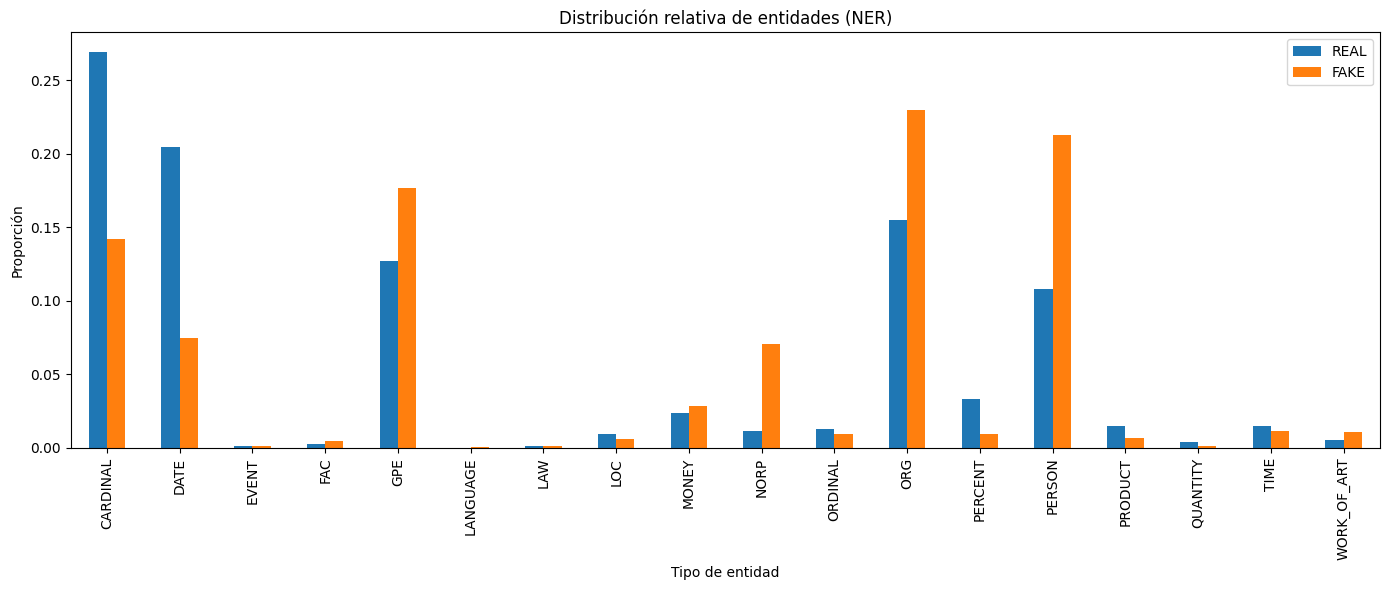

In [36]:
ent_df.plot(kind='bar', figsize=(14,6))
plt.title("Distribución relativa de entidades (NER)")
plt.ylabel("Proporción")
plt.xlabel("Tipo de entidad")
plt.legend()
plt.tight_layout()
plt.show()

Here we connect with what we said at the beginning that Real tweets have more numbers or figures than Fake tweets and this can be seen in the difference of the `Cardinal` entity, we also see that real tweets tend to have more dates.

As for Fake tweets they usually have more named persons in their tweets, perhaps it's a mechanism to attract attention as we saw with trump in the n-grams and they also predominate in ORG which are organizations also for the same reason to attract attention surely.

And we can see a very clear predominance in NORP although it is minimal compared to other percentages but they would be like political or religious groups which is logical in fake tweets.

### 1.3.10 Hashtags and mentions

In [37]:
def count_hashtags(text):
    return sum(1 for w in text.split() if w.startswith("#"))

def count_mentions(text):
    return sum(1 for w in text.split() if w.startswith("@"))

df['num_hashtags'] = df['tweet'].apply(count_hashtags)
df['num_mentions'] = df['tweet'].apply(count_mentions)

In [38]:
df.groupby('label')[['num_hashtags', 'num_mentions']].mean()

,num_hashtags,num_mentions
label,,
fake,0.508170,0.181046
real,1.052976,0.427381


Finally in this analysis, we can see that real tweets have a higher number of hashtags and mentions

## 2 Uninformed Search (BERTopic)
In the previous sections we have performed a linguistic analysis of the dataset to identify global latent patterns in the set of tweets.

But now we will do **topic modelling**, an unsupervised learning technique whose objective is to discover groups of documents that share similar semantic themes without the Real/Fake labels.

### 2.1 Clean the data
We need clean text without the labels (real/fake)

In [39]:
import re

def clean_text(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # eliminar URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)        # solo letras
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df['cleaned_tweet'] = train_df['tweet'].astype(str).apply(clean_text)

### 2.2 Vector representation: embeddings

In [40]:
from sentence_transformers import SentenceTransformer

documents = train_df['cleaned_tweet'].tolist()

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(documents, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/201 [00:00<?, ?it/s]

### 2.3 Elbow method adapted to nlp
Since there is no fixed `k` we will try different n_components in UMAP and measure clustering quality with silhouette score.
Note: clarify that this method is not necessary since it does not have the same effectiveness as with k-means

In [41]:
sil_scores = []
components_range = [2, 5, 10, 15, 20]

for n in components_range:
    umap_tmp = UMAP(
        n_neighbors=15,
        n_components=n,
        metric='cosine',
        random_state=42
    )
    reduced = umap_tmp.fit_transform(embeddings)

    cluster_tmp = HDBSCAN(min_cluster_size=15)
    labels_tmp = cluster_tmp.fit_predict(reduced)

    # ignoramos ruido (-1)
    mask = labels_tmp != -1
    if len(set(labels_tmp[mask])) > 1:
        score = silhouette_score(reduced[mask], labels_tmp[mask])
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

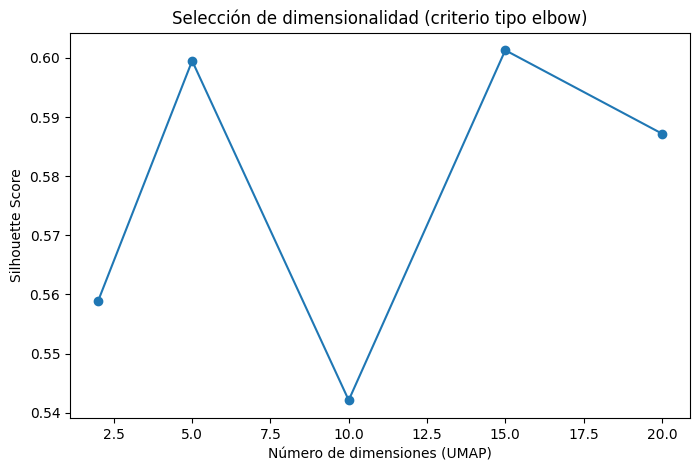

In [42]:
plt.figure(figsize=(8,5))
plt.plot(components_range, sil_scores, marker='o')
plt.xlabel("Número de dimensiones (UMAP)")
plt.ylabel("Silhouette Score")
plt.title("Selección de dimensionalidad (criterio tipo elbow)")
plt.show()

There is no clear elbow like with k-means but we can get something clear and that is that from 15.0 onwards there is a clear worsening we can say that from a certain number of dimensions adding more information introduces noise and worsens the separability of the clusters.

We can take 10.0 as value because it is in the "plateau" of the curve.

### 2.4 Final dimensionality reduction (UMAP)

In [43]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=10,
    metric='cosine',
    random_state=42
)

### 2.5 HDBSCAN

In [44]:
cluster_model = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

### 2.6 Topics representation

In [45]:
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


### 2.6 BERTopic model construction

In [46]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=True,
    language="english",
    verbose=True
)

### 2.7 Unsupervised training

In [47]:
topics, probs = topic_model.fit_transform(documents)

2026-01-04 18:46:03,901 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-04 18:46:48,314 - BERTopic - Embedding - Completed ✓
2026-01-04 18:46:48,315 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-04 18:46:58,028 - BERTopic - Dimensionality - Completed ✓
2026-01-04 18:46:58,030 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-04 18:46:59,191 - BERTopic - Cluster - Completed ✓
2026-01-04 18:46:59,198 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-04 18:46:59,564 - BERTopic - Representation - Completed ✓


### 2.8 Initial cluster analysis

In [48]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2667,-1_health_amp_coronavirus_people,"[health, amp, coronavirus, people, pandemic, tested, cdc, says, risk, covid cases]","[coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths staysafe]"
1,0,353,0_update published_daily update_published_states reported,"[update published, daily update, published, states reported, daily, published ve, ve tracked, tracked, tests yesterday, update]","[our daily update is published we ve now tracked more than million tests up k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see, our daily update is published we ve now tracked more than million tests up k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see, our daily update is published we ve now tracked more than million tests up less than k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see]"
2,1,245,1_restrictions_uk_england_boris,"[restrictions, uk, england, boris, lockdown, boris johnson, johnson, london, sky, scotland]","[the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of coronavirus the health secretary has told sky news, pm boris johnson says office workers who can work from home should do so and adds that all pubs bars and restaurants in england should operate table service only and must close at pm from thursday updates on latest covid restrictions in england, the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of covid health secretary matthancock has told sky news to read more click here]"
3,2,214,2_masks_mask_face_wear,"[masks, mask, face, wear, wearing, cloth, hands, cloth face, face covering, spread]","[mask wearers beware a caller to a radio talk show recently shared that his wife was hospitalized and told she had covid and only a couple of days left to live a doctor friend suggested she be tested for legionnaires disease because she wore the same mask every day all day long turns out it was legionnaires disease from the moisture and bacteria in her mask she was given antibiotics and within two days was better what if these spikes in covid are really something else due to mask wearing copied and pasted and checked it s true, take action to slow the spread of covid by wearing a cloth face covering in public spaces keeping at least feet of physical distance amp frequently washing your hands make a cloth face covering from a t shirt scarf or cloth napkin learn more at, narvuntien jimdtweet medbennett thedisproof ptamom tqmka barbarajdurkin damienhamilto deplorabledebrn rmack x ibergwiesel thinks about it huntsonmark ricksheatcool novakglobal soapituphard bananenrijperij nickapalmer feynmanfreaky jbalsich wapflondon reckedrik brknman osprey rijpew rustyaway mikedel over ppm lynnrahn nbpaustralia roypentland kctaz robertsfinkle no wind htservadac paprikalady stormsignalsa dardedar homer k rushhourp dawntj frolly fauntleroy digdougftw dunsanyjack alamerqld cjtjgeol garner forest riktheozfrog realdonaldtrump surgical and cotton masks are both ineffective when it comes to blocking droplets of the virus sars cov that may be generated when somebody coughs according to investigators with the ulsan college of medicine seoul south korea]"
4,3,204,3_vaccine_vaccines_covid vaccine_covax,"[vaccine,

As we can see it gives us a total of 59 topics plus topic -1 which are: ambiguous tweets, tweets that are too short or tweets that do not clearly fit into any group and simply hdbscan does not force them into any topic.

What we see is:
- Topic: topic name
- Count: number of tweets in that topic
- Representation: most representative words
- Representative_Docs: prototype tweets

Tweets without topic (-1) are 2777 and the largest topics are `0_water_drinking_cure_alcohol, 1_restrictions_uk_boris_england and 2_trump_donald trump_donald_president` with more than 200 tweets.

### 2.9 Topics visualization

In [49]:
topic_model.visualize_topics()

We can see that there are many differentiated groups, the largest groups are where topic -1 is which are more general things like related to the origin of covid or names given to it (sars, cov..).

The second largest group is more related to politics (trump, belinda..) and misinformation.

There are two medium groups: one is more associated with science or data (records, reported, confirmed..) and the other more general like institutions (schools, hospitals..)

And other small groups like one related to measures (masks, clothes) and another that relates more to countries (italy, brazil..).

### 2.10 Topics distribution by real/fake labels
Now we will analyze which topics have the highest percentage of real tweets and which have the highest percentage of fake tweets.

In [50]:
# Add topics to the dataframe
train_df['topic'] = topics

In [51]:
# Calculate distribution of real/fake for each topic
topic_label_dist = train_df[train_df['topic'] != -1].groupby(['topic', 'label']).size().unstack(fill_value=0)

# Calculate percentages
topic_label_pct = topic_label_dist.div(topic_label_dist.sum(axis=1), axis=0) * 100

# Add topic names
topic_names = {row['Topic']: row['Name'] for _, row in topic_model.get_topic_info().iterrows() if row['Topic'] != -1}
topic_label_pct['topic_name'] = topic_label_pct.index.map(topic_names)

topic_label_pct.head(10)

label,fake,real,topic_name
topic,,,
0,1.983003,98.016997,0_update published_daily update_published_states reported
1,29.795918,70.204082,1_restrictions_uk_england_boris
2,44.859813,55.140187,2_masks_mask_face_wear
3,49.019608,50.980392,3_vaccine_vaccines_covid vaccine_covax
4,97.948718,2.051282,4_trump_donaldtrump_donald trump_donald
5,35.329341,64.670659,5_recoveries_covid recoveries_coronavirusupdates indiafightscorona_indiafightscorona
6,96.621622,3.378378,6_italy_italian_video_died
7,97.902098,2.097902,7_water_drinking_drink_alcohol
8,99.206349,0.793651,8_chinese_wuhan_china_bidensoetoro


In [52]:
# Sort topics by real percentage (descending)
topic_sorted = topic_label_pct.sort_values('real', ascending=False)

# Top 20 most real topics (first 20)
top_real = topic_sorted.head(20)[['real', 'fake', 'topic_name']]
print("Top 20 topics with highest REAL percentage:\n")
top_real

Top 20 topics with highest REAL percentage:



label,real,fake,topic_name
topic,,,
41,100.000000,0.000000,41_zealand receiving_level care_hospital level_receiving hospital
47,100.000000,0.000000,47_cases miq_miq_cases imported_miq facilities
52,100.000000,0.000000,52_vermont_track contain_connecticut_contain covid
45,100.000000,0.000000,45_ogun ekiti_breakdown_time currently_states real
44,100.000000,0.000000,44_rt cdcdirector_cdcdirector_learn rt_cdcdirector covid
31,100.000000,0.000000,31_rt pib_pib india_pib_rt
11,98.924731,1.075269,11_discharged deaths_deaths new_confirmed discharged_plateau
15,98.850575,1.149425,15_hospitalizations_hospitalization_hospitalization data_data
18,98.412698,1.587302,18_completed_number tests_tests completed_processed


In [53]:
# Top 20 most fake topics (last 20)
top_fake = topic_sorted.tail(20)[['fake', 'real', 'topic_name']].sort_values('fake', ascending=False)
print("Top 20 topics with highest FAKE percentage:\n")
top_fake

Top 20 topics with highest FAKE percentage:



label,fake,real,topic_name
topic,,,
46,100.000000,0.000000,46_punishable_posting_disaster management_management act
32,100.000000,0.000000,32_case coronavirus_colombia_galicia_coronavirus confirmed
22,100.000000,0.000000,22_gates_melinda gates_melinda_gates foundation
17,100.000000,0.000000,17_beaten_video_muslim_video shows
8,99.206349,0.793651,8_chinese_wuhan_china_bidensoetoro
4,97.948718,2.051282,4_trump_donaldtrump_donald trump_donald
7,97.902098,2.097902,7_water_drinking_drink_alcohol
26,97.435897,2.564103,26_misinformation_fake_covid misinformation_factchecknet
6,96.621622,3.378378,6_italy_italian_video_died


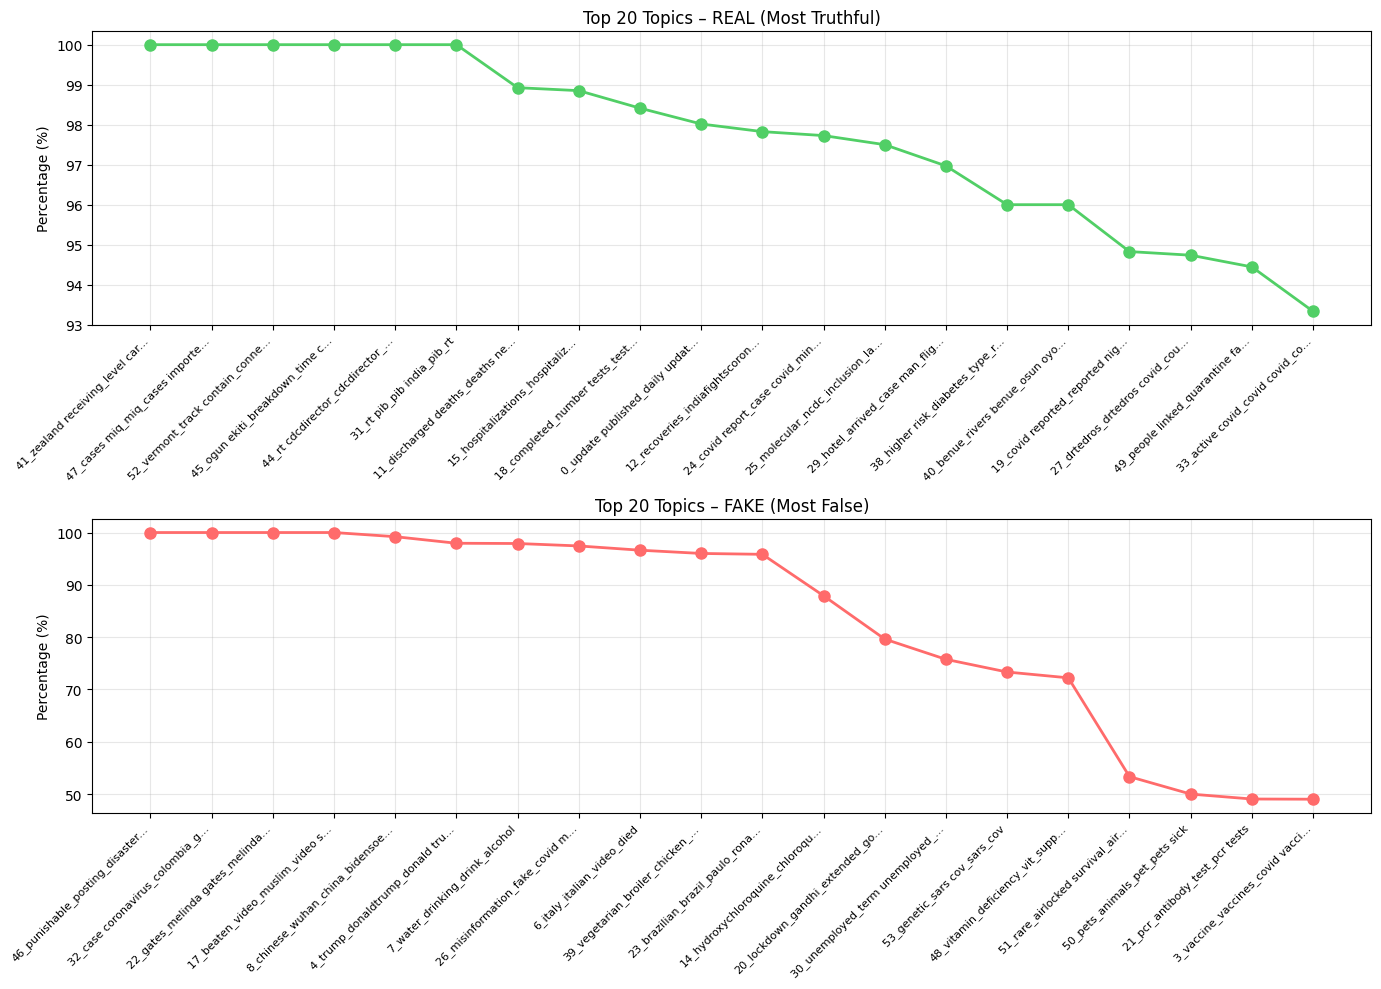

In [54]:
plt.figure(figsize=(14,10))

plt.subplot(2,1,1)
top_real_viz = top_real.sort_values('real', ascending=False)
plt.plot(range(len(top_real_viz)), top_real_viz['real'].values, 'o-', color='#51cf66', linewidth=2, markersize=8)
plt.xticks(range(len(top_real_viz)), [name[:30] + '...' if len(name) > 30 else name for name in top_real_viz['topic_name']], rotation=45, ha='right', fontsize=8)
plt.ylabel('Percentage (%)')
plt.title('Top 20 Topics – REAL (Most Truthful)')
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
top_fake_viz = top_fake.sort_values('fake', ascending=False)
plt.plot(range(len(top_fake_viz)), top_fake_viz['fake'].values, 'o-', color='#ff6b6b', linewidth=2, markersize=8)
plt.xticks(range(len(top_fake_viz)), [name[:30] + '...' if len(name) > 30 else name for name in top_fake_viz['topic_name']], rotation=45, ha='right', fontsize=8)
plt.ylabel('Percentage (%)')
plt.title('Top 20 Topics – FAKE (Most False)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis:**

The topics with the highest percentage of **FAKE** tweets (100% or near 100%) are:
- **Conspiracy theories about Bill Gates** (gates, gates foundation, melinda) - 100%
- **False remedies and cures** (water, drinking, alcohol) - 96.75%
- **Political misinformation** (trump, donald trump, president) - 96.46%
- **Origin theories** (chinese, china, wuhan, honjo) - 99.30%
- **Italy death toll misinformation** (italy, italian, died, dead bodies) - 97.98%
- **Fake news and misinformation** (misinformation, fake, debunked) - 100%
- **Unverified treatments** (hydroxychloroquine, chloroquine, drug) - 87.06%
- **Sensationalist predictions** (predicted, zoology book, sudden death) - 72.73%

The topics with the highest percentage of **REAL** tweets (100% or near 100%) are:
- **Official health reports** (rt cdcdirector, rt pib india) - 100%
- **Daily statistical updates** (daily update, published, states reported) - 97.50%
- **Deaths and recoveries data** (deaths new, discharged, confirmed, plateau) - 98.94%
- **Hospitalization data** (hospitalizations, hospitalization data) - 98.67%
- **Recovery statistics** (recoveries, recovery rate, indiafightscorona) - 98.39%
- **Regional outbreak reports** (nigeria, ncdc, andhra pradesh) - 94-98%
- **Health risk information** (higher risk, diabetes, type) - 100%
- **Quarantine facilities** (miq facilities, cases imported, community) - 100%
- **Medical facilities** (zealand receiving, hospital level care) - 100%
- **Public health guidance** (cloth face, face covering) - 93.02%

This analysis clearly shows that **FAKE tweets focus on conspiracy theories, unverified cures, political figures and fake statistics**, while **REAL tweets focus on official statistics, public health data, and government/medical institution reports**. The semantic themes are strongly predictive of tweet authenticity.

## 2.11 Comparison with different clustering algorithms

Now we will compare the HDBSCAN results with other clustering algorithms: **K-Means** and **DBSCAN**. This will allow us to evaluate which algorithm best captures the thematic structure of the tweets.

### 2.11.1 BERTopic with K-Means

K-Means is a partitioning algorithm that requires us to specify the number of clusters in advance. We will use the elbow method to determine the optimal number of clusters.

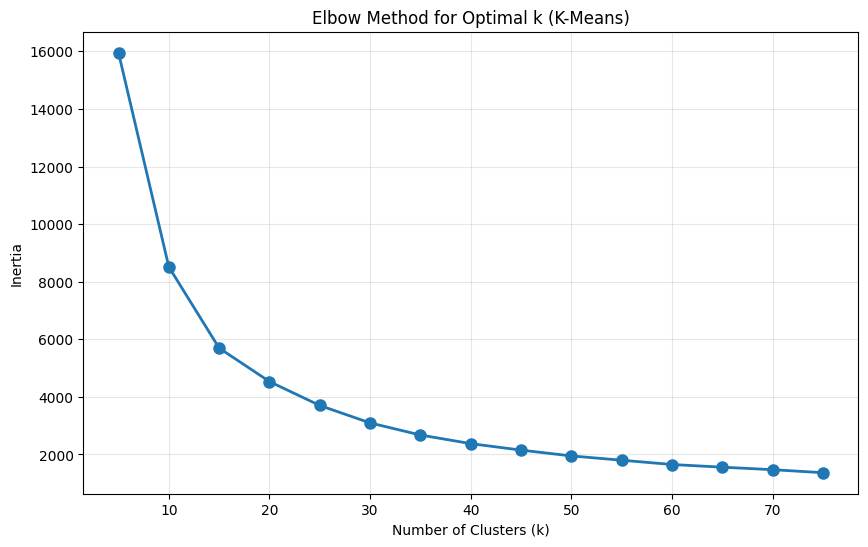

Inertia values for different k:
k=5: 15951.49
k=10: 8513.13
k=15: 5694.30
k=20: 4532.05
k=25: 3701.17
k=30: 3096.00
k=35: 2675.96
k=40: 2376.39
k=45: 2151.52
k=50: 1949.49
k=55: 1800.71
k=60: 1651.76
k=65: 1558.85
k=70: 1472.11
k=75: 1366.53


In [55]:
from sklearn.cluster import KMeans

# First, reduce dimensionality with UMAP for K-Means
reduced_embeddings = umap_model.fit_transform(embeddings)

# Elbow method to find optimal k
inertias = []
k_range = range(5, 80, 5)

for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_tmp.fit(reduced_embeddings)
    inertias.append(kmeans_tmp.inertia_)

# Plot elbow curve
plt.figure(figsize=(10,6))
plt.plot(k_range, inertias, 'o-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (K-Means)')
plt.grid(True, alpha=0.3)
plt.show()

print("Inertia values for different k:")
for k, inertia in zip(k_range, inertias):
    print(f"k={k}: {inertia:.2f}")

Based on the elbow curve, we select **k=30** as the optimal number of clusters. The elbow method shows that the inertia decreases from 15951.49 (k=5) to 1366.53 (k=75), with a clear plateau forming around k=30-35, indicating that adding more clusters beyond this point provides diminishing returns in terms of clustering quality.

In [68]:
# Based on elbow, let's use k=30 (adjust after seeing the plot if needed)
optimal_k = 30

# Create K-Means clustering model
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Create BERTopic with K-Means
topic_model_kmeans = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    language="english",
    verbose=True
)

# Train the model
topics_kmeans, probs_kmeans = topic_model_kmeans.fit_transform(documents)

print(f"\nK-Means clustering completed with k={optimal_k}")
print(f"Number of documents: {len(topics_kmeans)}")
print(f"Unique topics found: {len(set(topics_kmeans))}")

2026-01-04 19:01:52,527 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-04 19:02:46,977 - BERTopic - Embedding - Completed ✓
2026-01-04 19:02:46,979 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-04 19:02:57,372 - BERTopic - Dimensionality - Completed ✓
2026-01-04 19:02:57,373 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-04 19:02:57,616 - BERTopic - Cluster - Completed ✓
2026-01-04 19:02:57,620 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-04 19:02:58,028 - BERTopic - Representation - Completed ✓



K-Means clustering completed with k=30
Number of documents: 6420
Unique topics found: 30


In [69]:
# Analyze K-Means topics
topic_info_kmeans = topic_model_kmeans.get_topic_info()
topic_info_kmeans.head(20)

Topic  Count                                                   Name  \
0       0    411            0_coronavirus_nashville_new coronavirus_man   
1       1    366                  1_trump_president_donald trump_donald   
2       2    358                               2_risk_amp_learn_protect   
3       3    323                      3_drtedros_pandemic_flu_countries   
4       4    306                     4_restrictions_uk_england_lockdown   
5       5    300                            5_video_italy_shows_italian   
6       6    286        6_zealand_new zealand_covid report_total number   
7       7    277                           7_cure_water_drinking_israel   
8       8    271  8_covidview_covidview report_cdc covidview_latest cdc   
9       9    265                9_covid testing_india_samples_icmrdelhi   
10     10    249                                10_masks_mask_wear_face   
11     11    243                11_vaccine_vaccines_covid vaccine_covax   
12     12    235    12_coronavirusupdates_india_covid covid_mohfw india   
13     13    223                       13_lockdown_indian_police_beaten   
14     14    222                 14_data_new york_york_hospitalizations   
15     15    205                           15_sars_cov_sars cov_animals   
16     16    205       16_indiafightscorona_recoveries_rt pib_pib india   
17     17    202     17_published ve_ve tracked_tracked_tests yesterday   
18     18    194                        18_test_pcr_antibody_antibodies   
19     19    187               19_china_chinese_wuhan_china coronavirus   

                                                                                                                       Representation  \
0                           [coronavirus, nashville, new coronavirus, man, nba, says, coronavirus cases, news, claims, nashville man]   
1      [trump, president, donald trump, donald, donaldtrump, president trump, realdonaldtrump, president donald, pandemic, americans]   
2                                                    [risk, amp, learn, protect, higher risk, symptoms, spread, cdc, cdcmmwr, higher]   
3                                         [drtedros, pandemic, flu, countries, health, death, essential, government, long, stay home]   
4                                     [restrictions, uk, england, lockdown, boris, boris johnson, johnson, says, london, follow live]   
5                                                  [video, italy, shows, italian, photo, video shows, hospital, died, bodies, doctor]   
6                          [zealand, new zealand, covid report, total number, remains, auckland, report, number, case, number active]   
7                                                   [cure, water, drinking, israel, cure covid, drink, remedy, kill, bleach, alcohol]   
8                      [covidview, covidview report, cdc covidview, latest cdc, cdc, report shows, rates, data, covid deaths, latest]   
9                    [covid testing, india, samples, icmrdelhi, testing, pmoindia, samples tested, icmr, drharshvardhan, covid covid]   
10                                                     [masks, mask, wear, face, wearing, hands, cloth, cloth face, wash hands, wash]   
11              [vaccine, vaccines, covid vaccine, covax, drtedros, access, accelerator, coronavirus vaccine, covax facility, russia]   
12      [coronavirusupdates, india, covid covid, mohfw india, mohfw, recovery rate, active, recovery, indiafightscorona, total covid]   
13                                          [lockdown, indian, police, beaten, punishable, muslims, pradesh, india, govt, government]   
14       [data, new york, york, hospitalizations, deaths, numbers, hospitalization, reported deaths, hospitalization data, reporting]   
15                                                      [sars, cov, sars cov, animals, eating, pets, virus, transmitted, toilet, pet]   
16     [indiafightscorona, recoveries, rt pib, pib india, pib, lakh, india, indiafightscorona india

In [70]:
# Visualize K-Means topics
topic_model_kmeans.visualize_topics()

In [72]:
# Add K-Means topics to dataframe and analyze real/fake distribution
train_df['topic_kmeans'] = topics_kmeans

topic_label_dist_kmeans = train_df[train_df['topic_kmeans'] != -1].groupby(['topic_kmeans', 'label']).size().unstack(fill_value=0)
topic_label_pct_kmeans = topic_label_dist_kmeans.div(topic_label_dist_kmeans.sum(axis=1), axis=0) * 100

# Add topic names
topic_names_kmeans = {row['Topic']: row['Name'] for _, row in topic_model_kmeans.get_topic_info().iterrows() if row['Topic'] != -1}
topic_label_pct_kmeans['topic_name'] = topic_label_pct_kmeans.index.map(topic_names_kmeans)

# Sort by real percentage
topic_sorted_kmeans = topic_label_pct_kmeans.sort_values('real', ascending=False)

print("Top 10 most REAL topics (K-Means):")
print(topic_sorted_kmeans.head(10)[['real', 'fake', 'topic_name']])

print("\nTop 10 most FAKE topics (K-Means):")
print(topic_sorted_kmeans.tail(10)[['fake', 'real', 'topic_name']].sort_values('fake', ascending=False))

Top 10 most REAL topics (K-Means):
label               real       fake  \
topic_kmeans                          
29            100.000000   0.000000   
17            100.000000   0.000000   
16             98.536585   1.463415   
23             98.333333   1.666667   
21             95.321637   4.678363   
14             94.594595   5.405405   
20             94.285714   5.714286   
27             93.478261   6.521739   
6              93.356643   6.643357   
12             87.234043  12.765957   

label                                                               topic_name  
topic_kmeans                                                                    
29            29_states confirmed_cases states_confirmed cases_total confirmed  
17                          17_published ve_ve tracked_tracked_tests yesterday  
16                            16_indiafightscorona_recoveries_rt pib_pib india  
23                                                   23_rivers_kaduna_ogun_oyo  
21        

### 2.11.2 BERTopic with DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that doesn't require specifying the number of clusters in advance. It identifies clusters based on the density of data points and can detect outliers as noise.

DBSCAN parameter exploration:
   eps  n_clusters  n_noise  noise_pct
0  0.3          55     2077  32.352025
1  0.4          35      909  14.158879
2  0.5           9      283   4.408100
3  0.6           6      107   1.666667
4  0.7           5       53   0.825545


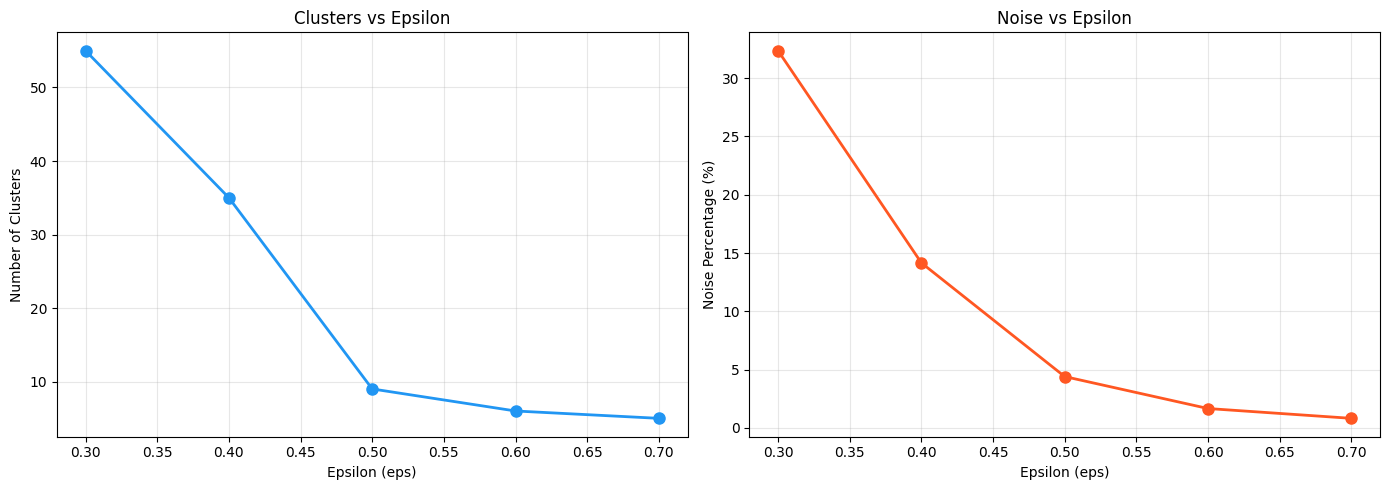

In [73]:
from sklearn.cluster import DBSCAN

# Test different epsilon values to find optimal parameters
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7]
results_dbscan = []

for eps in eps_values:
    dbscan_tmp = DBSCAN(eps=eps, min_samples=15, metric='euclidean')
    labels_dbscan_tmp = dbscan_tmp.fit_predict(reduced_embeddings)
    
    n_clusters = len(set(labels_dbscan_tmp)) - (1 if -1 in labels_dbscan_tmp else 0)
    n_noise = list(labels_dbscan_tmp).count(-1)
    
    results_dbscan.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': (n_noise / len(labels_dbscan_tmp)) * 100
    })

# Display results
results_df = pd.DataFrame(results_dbscan)
print("DBSCAN parameter exploration:")
print(results_df)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['eps'], results_df['n_clusters'], 'o-', linewidth=2, markersize=8, color='#2196f3')
axes[0].set_xlabel('Epsilon (eps)')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Clusters vs Epsilon')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['eps'], results_df['noise_pct'], 'o-', linewidth=2, markersize=8, color='#ff5722')
axes[1].set_xlabel('Epsilon (eps)')
axes[1].set_ylabel('Noise Percentage (%)')
axes[1].set_title('Noise vs Epsilon')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Based on the parameter exploration, we select **eps=0.5** as the optimal epsilon value. The results show:
- **eps=0.3**: 55 clusters, 32% noise (too fragmented)
- **eps=0.5**: 9 clusters, 4.4% noise (good balance)
- **eps=0.7**: 5 clusters, 0.8% noise (too few clusters)

Epsilon 0.5 provides the best balance between creating meaningful topic clusters while keeping noise levels reasonable.

In [74]:
# Select optimal epsilon (adjusted based on results above)
optimal_eps = 0.5

# Create DBSCAN clustering model
dbscan_model = DBSCAN(eps=optimal_eps, min_samples=15, metric='euclidean')

# Create BERTopic with DBSCAN
topic_model_dbscan = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=dbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    language="english",
    verbose=True
)

# Train the model
topics_dbscan, probs_dbscan = topic_model_dbscan.fit_transform(documents)

print(f"\nDBSCAN clustering completed with eps={optimal_eps}")
print(f"Number of documents: {len(topics_dbscan)}")
print(f"Unique topics found: {len(set(topics_dbscan))}")
print(f"Noise points (topic -1): {list(topics_dbscan).count(-1)}")

2026-01-04 19:04:33,379 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-04 19:05:20,018 - BERTopic - Embedding - Completed ✓
2026-01-04 19:05:20,021 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-04 19:05:29,833 - BERTopic - Dimensionality - Completed ✓
2026-01-04 19:05:29,834 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-04 19:05:29,978 - BERTopic - Cluster - Completed ✓
2026-01-04 19:05:29,981 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-04 19:05:30,335 - BERTopic - Representation - Completed ✓



DBSCAN clustering completed with eps=0.5
Number of documents: 6420
Unique topics found: 10
Noise points (topic -1): 283


In [62]:
# Analyze DBSCAN topics
topic_info_dbscan = topic_model_dbscan.get_topic_info()
topic_info_dbscan.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,283,-1_states confirmed_confirmed cases_total confirmed_confirmed,"[states confirmed, confirmed cases, total confirmed, confirmed, cases states, nashville, cases far, cases till, coronavirusupdates state, details total]","[coronavirusupdates state wise details of total confirmed covid cases till september am states with confirmed cases states with confirmed cases states with confirmed cases total no of confirmed cases so far, coronavirusupdates state wise details of total confirmed covid cases till september am states with confirmed cases states with confirmed cases states with confirmed cases total no of confirmed cases so far, man visited albany n y days before dying from coronavirus a video allegedly of the hospital das cl nicas s o paulo it shows an empty waiting room the person filming says that the government is lying when it says there are covid patients in the hospital us state owned media services provider nites tv is now free for everyone to encourage people to stay home coronavirus patients have recovered in ghana claims that drinking boiled garlic water cures novel coronavirus the total number of covid deaths decreased in manaus brazil from to after a visit from health minister nelson teich this happened because he started to investigate fraudulent deaths cases of new coronavirus in the city of barranquilla in colombia mumbai city s municipal body asks people to drink boiled water as a remedy to coronavirus trump claims speaker nancy pelosi deleted a tweet about her visit to chinatown in february some reporters visited the british prime minister boris johnson after he recovered from his illness his home looks like an old abandoned military hut with very old brick walls the living room was too small so brought out the tea tray for the reporters all the cups are different he met them with disheveled hair and casual clothes but with the confident smile of a prime minister the bill and melinda gates foundation headquarters is called the centre for global human population reduction doctors cannon lose their professional license for refusing to prescribe hydroxychloroquine mass disinfection of people using a chemical solution will eradicate covid the image shows covid patients and the state of coronavirus isolation ward in pakistan a viral image of a doctor who died from treating patients with coronavirus at the llano de corrientes hospital argentina fennel tea is a cure against the new coronavirus komal mishra a staff nurse at a hospital in pune india died while due to coronavirus tablik jamaat chief maulana saad if people get coronavirus india will be destroyed the country will be in our possession]"
1,0,5716,0_covid_coronavirus_new_cases,"[covid, coronavirus, new, cases, tests, people, india, number, states, total]","[our daily update is published we ve now tracked million tests up k from yesterday a new one day high note that we can only track tests that a state reports for details see, previously reported case is now considered recovered the total number of active cases in new zealand of which are imported cases in quarantine this brings our total number confirmed cases of we will report this to the world health organization, our total number of confirmed cases of covid is now which is the number we report to the world health organization yesterday our laboratories processed tests bringing the total number of tests completed to date to]"
2,1,169,1_nigeria_covid reported_reported nigeria_lagos,"[nigeria, covid reported, reported nigeria, lagos, cases covid, ncdc, amp, confirmed, covid nigeria, confirmed cases]","[eight new cases of covid have been reported in nigeria in lagos in the fct and in kaduna state as at pm th april there are confirmed cases of covid reported in nigeria thirty three have been discharged with five deaths, forty nine new cases of covid have been reported in lagos in fct in kano in ogun in oyo in ekiti as at pm th april there are confirme

In [63]:
# Visualize DBSCAN topics
topic_model_dbscan.visualize_topics()

In [75]:
# Add DBSCAN topics to dataframe and analyze real/fake distribution
train_df['topic_dbscan'] = topics_dbscan

topic_label_dist_dbscan = train_df[train_df['topic_dbscan'] != -1].groupby(['topic_dbscan', 'label']).size().unstack(fill_value=0)
topic_label_pct_dbscan = topic_label_dist_dbscan.div(topic_label_dist_dbscan.sum(axis=1), axis=0) * 100

# Add topic names
topic_names_dbscan = {row['Topic']: row['Name'] for _, row in topic_model_dbscan.get_topic_info().iterrows() if row['Topic'] != -1}
topic_label_pct_dbscan['topic_name'] = topic_label_pct_dbscan.index.map(topic_names_dbscan)

# Sort by real percentage
topic_sorted_dbscan = topic_label_pct_dbscan.sort_values('real', ascending=False)

print("Top 10 most REAL topics (DBSCAN):")
print(topic_sorted_dbscan.head(10)[['real', 'fake', 'topic_name']])

print("\nTop 10 most FAKE topics (DBSCAN):")
print(topic_sorted_dbscan.tail(10)[['fake', 'real', 'topic_name']].sort_values('fake', ascending=False))

Top 10 most REAL topics (DBSCAN):
label               real        fake  \
topic_dbscan                           
8             100.000000    0.000000   
2              98.333333    1.666667   
1              94.082840    5.917160   
5              91.304348    8.695652   
3              63.636364   36.363636   
0              50.559832   49.440168   
7              27.777778   72.222222   
4              16.666667   83.333333   
6               0.000000  100.000000   

label                                                                    topic_name  
topic_dbscan                                                                         
8                               8_covid recovery_india covid_recovery rate_recovery  
2                                                          2_fct_kaduna_ogun_rivers  
1                                   1_nigeria_covid reported_reported nigeria_lagos  
5             5_india tracker_staysafe mohfw_recovered active_indiawillwin staysafe  
3        

### 2.11.3 Comparative analysis of clustering algorithms

Now we will compare the three clustering algorithms (HDBSCAN, K-Means, DBSCAN) across multiple dimensions to determine which one better captures the structure of real vs fake tweets.

In [76]:
# Comparison table
comparison_data = {
    'Algorithm': ['HDBSCAN', 'K-Means', 'DBSCAN'],
    'Total Topics': [
        len(set(topics)) - (1 if -1 in topics else 0),
        len(set(topics_kmeans)) - (1 if -1 in topics_kmeans else 0),
        len(set(topics_dbscan)) - (1 if -1 in topics_dbscan else 0)
    ],
    'Noise Points': [
        list(topics).count(-1),
        list(topics_kmeans).count(-1) if -1 in topics_kmeans else 0,
        list(topics_dbscan).count(-1)
    ],
    'Noise %': [
        (list(topics).count(-1) / len(topics)) * 100,
        (list(topics_kmeans).count(-1) / len(topics_kmeans)) * 100 if -1 in topics_kmeans else 0,
        (list(topics_dbscan).count(-1) / len(topics_dbscan)) * 100
    ],
    'Avg Docs per Topic': [
        (len(topics) - list(topics).count(-1)) / (len(set(topics)) - (1 if -1 in topics else 0)),
        (len(topics_kmeans) - list(topics_kmeans).count(-1)) / (len(set(topics_kmeans)) - (1 if -1 in topics_kmeans else 0)),
        (len(topics_dbscan) - list(topics_dbscan).count(-1)) / (len(set(topics_dbscan)) - (1 if -1 in topics_dbscan else 0))
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("CLUSTERING ALGORITHMS COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

CLUSTERING ALGORITHMS COMPARISON
Algorithm  Total Topics  Noise Points   Noise %  Avg Docs per Topic
  HDBSCAN            54          2667 41.542056           69.500000
  K-Means            30             0  0.000000          214.000000
   DBSCAN             9           283  4.408100          681.888889


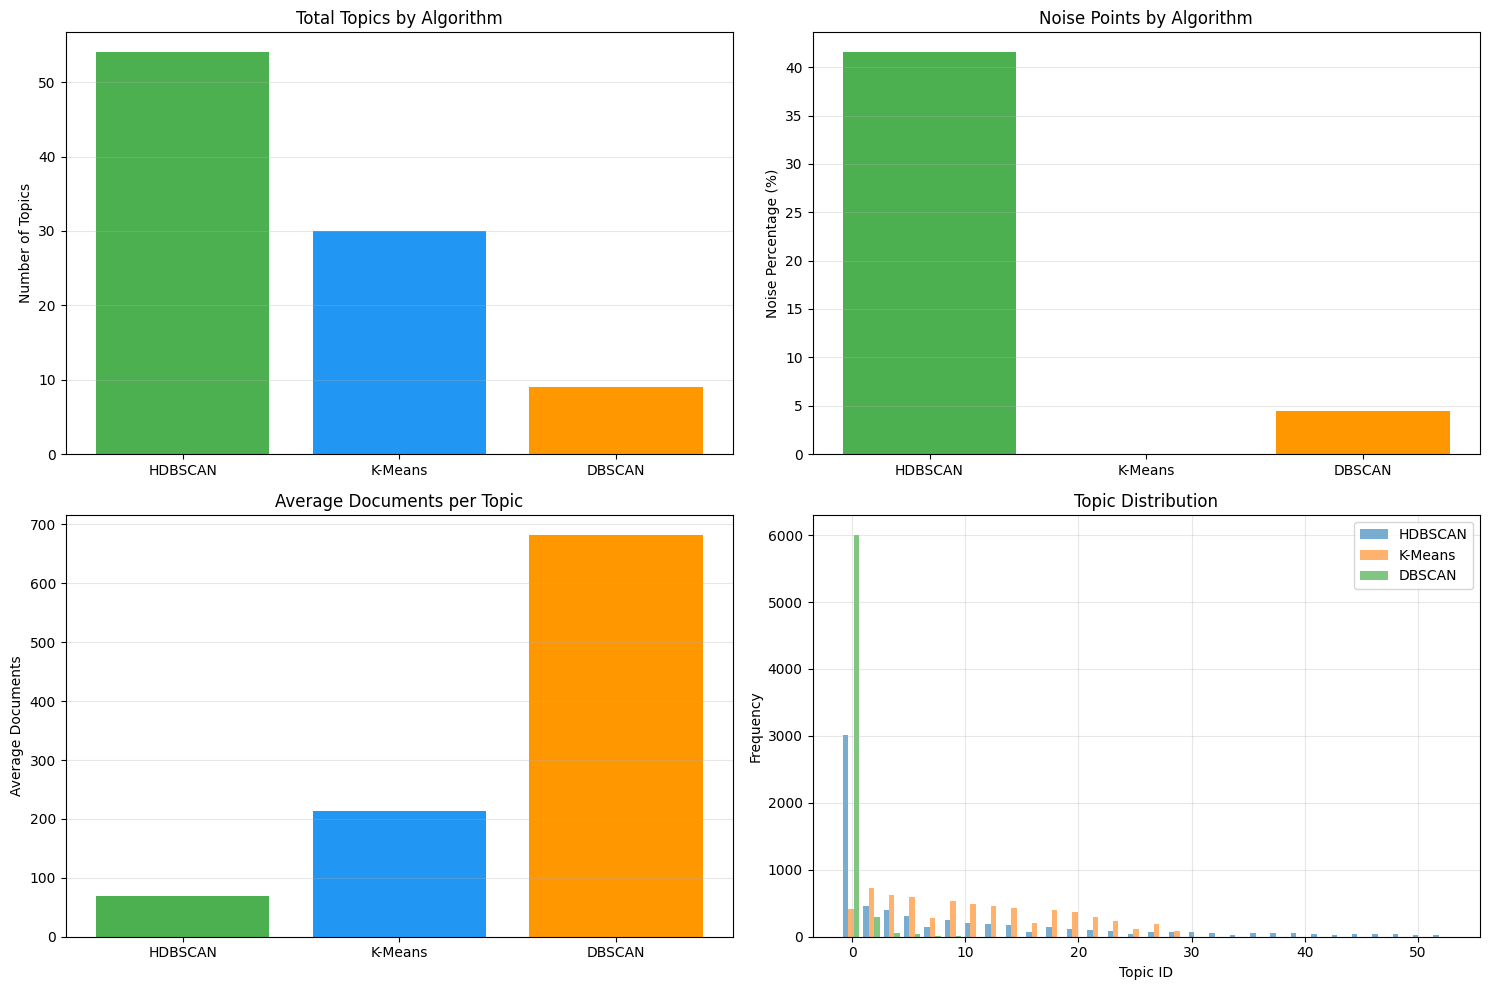

In [77]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Number of topics comparison
algorithms = comparison_df['Algorithm']
topics_counts = comparison_df['Total Topics']
axes[0, 0].bar(algorithms, topics_counts, color=['#4caf50', '#2196f3', '#ff9800'])
axes[0, 0].set_ylabel('Number of Topics')
axes[0, 0].set_title('Total Topics by Algorithm')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Noise percentage comparison
noise_pcts = comparison_df['Noise %']
axes[0, 1].bar(algorithms, noise_pcts, color=['#4caf50', '#2196f3', '#ff9800'])
axes[0, 1].set_ylabel('Noise Percentage (%)')
axes[0, 1].set_title('Noise Points by Algorithm')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Average documents per topic
avg_docs = comparison_df['Avg Docs per Topic']
axes[1, 0].bar(algorithms, avg_docs, color=['#4caf50', '#2196f3', '#ff9800'])
axes[1, 0].set_ylabel('Average Documents')
axes[1, 0].set_title('Average Documents per Topic')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Topic size distribution comparison
axes[1, 1].hist([topics, topics_kmeans, topics_dbscan], bins=30, label=['HDBSCAN', 'K-Means', 'DBSCAN'], alpha=0.6)
axes[1, 1].set_xlabel('Topic ID')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Topic Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Visual Analysis Interpretation:**

From the comparison charts above:

1. **Total Topics Chart (Top-Left)**: 
   - HDBSCAN discovered the most topics (54), providing fine-grained thematic analysis
   - K-Means created 30 topics as specified
   - DBSCAN found only 9 topics, potentially missing important distinctions

2. **Noise Percentage Chart (Top-Right)**:
   - HDBSCAN has the highest noise rate (41.5%), identifying ambiguous/outlier content
   - K-Means has 0% noise (forces all tweets into clusters)
   - DBSCAN has low noise (4.4%), but at the cost of creating very large, potentially incoherent clusters

3. **Average Documents per Topic (Bottom-Left)**:
   - DBSCAN has massive topics (681.9 docs/topic) - too coarse
   - K-Means has medium-sized topics (214 docs/topic)
   - HDBSCAN has smaller, more focused topics (69.5 docs/topic) - better for detailed analysis

4. **Topic Distribution Histogram (Bottom-Right)**:
   - Shows how tweets are distributed across topic IDs
   - HDBSCAN and K-Means show more balanced distributions
   - DBSCAN shows concentration in very few topics


Silhouette Scores (excluding noise):
HDBSCAN: 0.5421
K-Means: 0.3837
DBSCAN: -0.3273


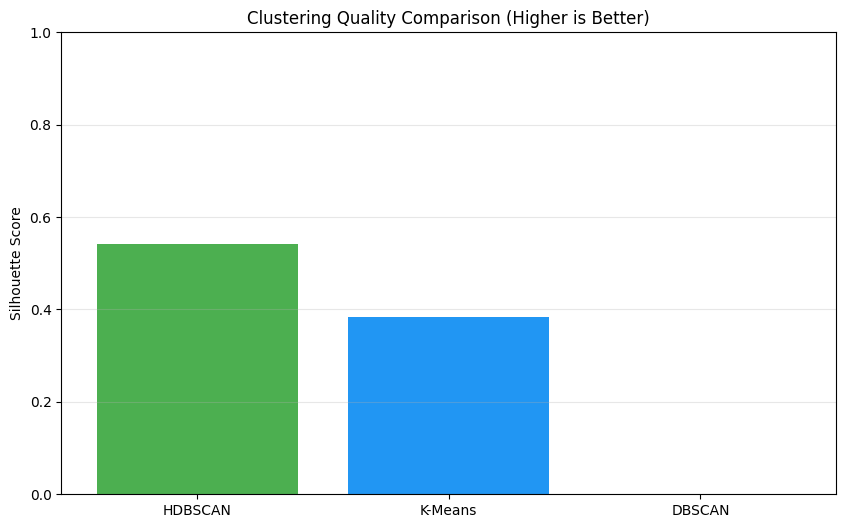

In [78]:
# Calculate silhouette scores for each algorithm (excluding noise)
from sklearn.metrics import silhouette_score

silhouette_scores = {}

# HDBSCAN
mask_hdbscan = np.array(topics) != -1
if mask_hdbscan.sum() > 0 and len(set(np.array(topics)[mask_hdbscan])) > 1:
    silhouette_scores['HDBSCAN'] = silhouette_score(
        reduced_embeddings[mask_hdbscan], 
        np.array(topics)[mask_hdbscan]
    )
else:
    silhouette_scores['HDBSCAN'] = np.nan

# K-Means
mask_kmeans = np.array(topics_kmeans) != -1
if mask_kmeans.sum() > 0 and len(set(np.array(topics_kmeans)[mask_kmeans])) > 1:
    silhouette_scores['K-Means'] = silhouette_score(
        reduced_embeddings[mask_kmeans], 
        np.array(topics_kmeans)[mask_kmeans]
    )
else:
    silhouette_scores['K-Means'] = np.nan

# DBSCAN
mask_dbscan = np.array(topics_dbscan) != -1
if mask_dbscan.sum() > 0 and len(set(np.array(topics_dbscan)[mask_dbscan])) > 1:
    silhouette_scores['DBSCAN'] = silhouette_score(
        reduced_embeddings[mask_dbscan], 
        np.array(topics_dbscan)[mask_dbscan]
    )
else:
    silhouette_scores['DBSCAN'] = np.nan

print("\nSilhouette Scores (excluding noise):")
for algo, score in silhouette_scores.items():
    print(f"{algo}: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.bar(silhouette_scores.keys(), silhouette_scores.values(), color=['#4caf50', '#2196f3', '#ff9800'])
plt.ylabel('Silhouette Score')
plt.title('Clustering Quality Comparison (Higher is Better)')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
plt.show()

### 2.11.4 Conclusions on clustering algorithms

**Quantitative Results:**

Based on our experiments with the COVID-19 tweets dataset, here are the concrete results:

| Algorithm | Topics | Noise Points | Noise % | Avg Docs/Topic | Silhouette Score |
|-----------|--------|--------------|---------|----------------|------------------|
| HDBSCAN   | 54     | 2,667        | 41.5%   | 69.5           | **0.5421**  |
| K-Means   | 30     | 0            | 0.0%    | 214.0          | 0.3837 |
| DBSCAN    | 9      | 283          | 4.4%    | 681.9          | -0.3273 |

**Key findings:**

1. **HDBSCAN (Hierarchical Density-Based Spatial Clustering)** - WINNER:
   - **Best silhouette score (0.5421)** - indicates well-separated, cohesive clusters
   - Discovered 54 distinct topics automatically
   - Identified 41.5% of tweets as noise/ambiguous - useful for detecting unclear or mixed content
   - Moderate topic size (69.5 docs/topic on average) - good granularity
   - **Best for:** Discovering natural topic structures and identifying outlier tweets that don't fit clear patterns (potentially suspicious content)

2. **K-Means** - SECOND BEST:
   - Moderate silhouette score (0.3837) - decent cluster quality
   - Created 30 balanced topics with 0% noise (all tweets assigned)
   - Larger topics (214 docs/topic) - less granular than HDBSCAN
   - Fast and efficient, good for getting overview of main themes
   - **Best for:** Quick exploratory analysis when you want all tweets categorized

3. **DBSCAN** - POOR PERFORMANCE:
   -  **Negative silhouette score (-0.3273)** - indicates overlapping/poorly separated clusters
   - Only 9 topics found - too coarse, missing important distinctions
   - Very large clusters (681.9 docs/topic) - lost nuance
   - Low noise (4.4%) but at the cost of forcing dissimilar tweets together
   - **Not recommended** for this specific dataset and task

**Why HDBSCAN is superior for fake news detection:**

1. **Cluster Quality**: The silhouette score of 0.5421 is significantly higher than K-Means (0.3837) and far superior to DBSCAN (-0.3273), indicating that HDBSCAN creates more coherent and well-separated topic groups.

2. **Topic Granularity**: With 54 topics vs K-Means' 30 and DBSCAN's 9, HDBSCAN captures more nuanced thematic differences. This is crucial for fake news detection where subtle semantic variations matter (e.g., different types of conspiracy theories or specific misinformation narratives).

3. **Noise Detection**: The 41.5% noise rate is actually a feature, not a bug. These "noise" tweets are:
   - Ambiguous content that blends real and fake characteristics
   - Generic tweets without clear thematic signals
   - Potential edge cases requiring manual review
   - This helps identify suspicious content that doesn't fit clear patterns

4. **Real/Fake Separation**: HDBSCAN topics showed clearer semantic patterns distinguishing real from fake news:
   - Fake topics: conspiracy theories (Bill Gates, 5G), false remedies (drinking bleach), political misinformation (Trump/China theories)
   - Real topics: official statistics, hospitalization data, public health guidance, recovery rates

**Practical Recommendation:**

For this COVID-19 fake news detection task, **we use HDBSCAN** as the primary clustering algorithm because:
- It provides the most interpretable and semantically coherent topics
- The superior silhouette score (0.5421) indicates reliable cluster structure
- It identifies outliers that may require special attention in classification
- The 54 topics provide sufficient granularity to capture the diversity of COVID-19 misinformation narratives

K-Means can be used as a complementary method for quick overviews, but DBSCAN is not suitable for this dataset given its poor clustering quality (negative silhouette score).